In [218]:
#1. Setup and Imports

from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [219]:
#2. The Abstract Problem Interface

class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [220]:
#3. The Node Class

@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [221]:
#4. Helper Functions

def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [222]:
#5. Implementing the Grid Search Problem

MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state):
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal



    def in_bounds(self, state):
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state):
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        row, col = state
        # 2. For each action in MOVES:
        # a. Compute the neighbour cell.
        for action, (dr, dc) in MOVES.items():
          new_state = (row + dr , col + dc)


        # b. Check that it is in bounds.
        # c. Check that it is free.
        # d. If valid, add the action name to legal_actions.
          if self.in_bounds(new_state) and self.is_free(new_state):
            legal_actions.append(action)
          # 3. Return legal_actions.
        return legal_actions


    def result(self, state, action):
        # TODO 3:
        # Return the next state after applying action to state.
        row, col = state
        dr, dc = MOVES[action]
        return (row + dr, col + dc)

    def action_cost(self, state, action, next_state):
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1


In [223]:
#5.1 Self-Check for GridProblem

test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")





GridProblem self-check passed.


In [224]:
#6. Sample Drone Map

sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [225]:
#7. Visualisation Helper

def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

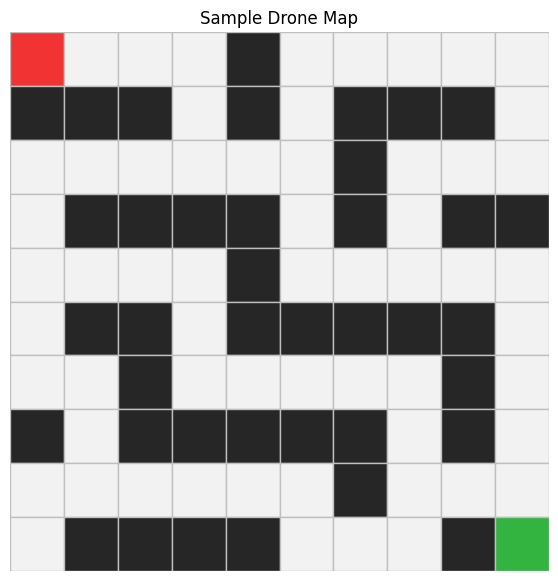

In [226]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [227]:

from abc import ABC, abstractmethod
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""


    def expand(self, Problem, node):
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).


        s = node.state
        for action in problem.actions(s):
          s_prime = problem.result(s, action)
          cost = node.path_cost + problem.action_cost(s, action, s_prime)
          yield Node(state=s_prime, parent=node, action=action, path_cost=cost)


In [228]:
#9. Breadth-First Search (BFS)

from collections import deque

class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem):
        algorithm = "BFS"


        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        # 1. Create the initial node from problem.initial_state().

        initial_node = Node(problem.initial_state())

        # 2. If the initial state is the goal, return success.
        if problem.is_goal(initial_node.state):
           return SearchResult(
               algorithm = algorithm,
               status = "success",
               solution = initial_node,
               nodes_expanded = 0,
               max_frontier_size = 1

           )


        # 3. Create a deque frontier and add the initial node.
        frontier = deque([initial_node])

        # 4. Create a reached set and add the initial state.
        reached = {initial_node.state}

        # 5. While frontier is not empty:

        nodes_expanded = 0

        max_frontier_size = 1

        while frontier:
          #       a. pop from the LEFT of the deque.
          node = frontier.popleft()
          #       b. increment nodes_expanded.
          nodes_expanded += 1
          #       c. expand the node

          for child in self.expand(problem, node):

          # i. if child is goal, return success.
            if problem.is_goal(child.state):
              return SearchResult(
                  algorithm = algorithm,
                  status = "success",
                  solution = child,
                  nodes_expanded = nodes_expanded,
                  max_frontier_size = max_frontier_size,
                  reached_count = len(reached)
            )
          # ii. if child.state is not in reached:
            if child.state not in reached:
            # add child.state to reache
              reached.add(child.state)
            # append child to frontier.
              frontier.append(child)
          # e. update max_frontier_size.
          max_frontier_size = max(max_frontier_size, len(frontier))

    # 6. Return failure if no solution is found.


        return SearchResult(
            algorithm = algorithm,
            status = "failure",
            solution = None,
            nodes_expanded= nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count = len(reached)

        )



In [229]:
#10. Depth-First Search (DFS)

class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem):
        algorithm = "DFS"


        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        initial_node = Node(problem.initial_state())
        # 2. If the initial state is the goal, return success.
        if  problem.is_goal(initial_node.state):
          return SearchResult(
              algorithm = algorithm,
              status ="success",
              solution = initial_node,
              nodes_expanded = 0,
              max_frontier_size=1,

          )
        # 3. Use a Python list as the stack frontier.
        frontier = [initial_node]
        # 4. Use a reached set.
        reached = {initial_node.state}


        nodes_expanded = 0
        max_frontier_size = 1

        # 5. While frontier is not empty:
        while frontier:



        #       a. pop from the end of the list.

          node = frontier.pop()

        #       b. increment nodes_expanded.

          nodes_expanded += 1

        #       c. expand the node.
          children = list(self.expand(problem, node))

          for child in reversed(children):
            if problem.is_goal(child.state):
              return SearchResult(
                  algorithm = algorithm,
                  status = " success",
                  solution = child,
                  nodes_expanded=nodes_expanded,
                  max_frontier_size=max_frontier_size,
                  reached_count = len(reached)
              )


        #       d. add unreached children to the stack.
            if child.state not in reached:
              reached.add(child.state)

              frontier.append(child)


        #       e. update max_frontier_size.

          max_frontier_size = max(max_frontier_size, len(frontier))
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        return SearchResult(
            algorithm = algorithm,
            status = "failure",
            solution = None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)

  )



In [230]:
from os import path
from typing import Any, Dict, Iterable, List, Optional, Tuple
# 11. Depth-Limited Search (DLS)


class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
            current_path={initial_node.state}
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
        current_path: set,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").


        if problem.is_goal(node.state):
          return node, "success"


        # 2. Else if node.depth >= limit, return (None, "cutoff").
        if node.depth >= limit:
          return None, "cutoff"





        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].

        metrics["nodes_expanded"] += 1
        #       b. set cutoff_occurred = False.
        cutoff_occured = False
        #       c. for each child in expand(problem, node):
        metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)



        for child in self.expand(problem, node):


        #             i. skip the child if child.state already appears on the current path.
          if child.state in current_path:
            continue

          new_path = current_path | {child.state}

        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.

          result, status = self._recursive_dls(
            problem=problem,
            node= child,
            limit=limit,
            metrics=metrics,
            current_stack_size= current_stack_size + 1,
            current_path = new_path                                  )
        #            iv. if result is "success", return success immediately.

          if status == "success":

            return result, "success"


        #             v. if result is "cutoff", set cutoff_occurred = True.

          elif status == "cutoff":
            cutoff_occurred = True

        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")

        if cutoff_occured:
          return None, "cutoff"
        else:
          return None, "failure"


In [231]:
# 12. Iterative Deepening Search (IDS)

class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.

        iteration_log = []


        # 2. Accumulate total nodes expanded across all DLS iterations.

        total_nodes_expanded = 0
        max_stack_size = 0
        # 3. Track the maximum stack size seen in any DLS run.
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)



        dls = DepthLimitedSearch()

        for limit in range(0, max_depth + 1):
          result = dls.search(problem, limit = limit)

          total_nodes_expanded += result.nodes_expanded
          max_stack_size = max(max_stack_size, result.max_frontier_size)

          iteration_log.append({"limit":limit, "status":result.status})


        # 4. If a DLS run returns success, return a SearchResult for IDS.

          if result.status ==  "success":
            return SearchResult(
            algorithm=algorithm,
            status="success",
            solution=result.solution,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=0,
            limit=limit,
            iterations = iteration_log

            )



        # 5. If a DLS run returns failure, IDS can stop early and return failure.

        if result.status == "failure":
          return SearchResult(
              algorithm = algorithm,
              status = "failure",
              solution = None,
              nodes_expanded = total_nodes_expanded,
              max_frontier_size = max_stack_size,
              reached_count=0,
              limit = limit,
              iterations = iteration_log
          )
        # 6. If all limits return cutoff up to max_depth, return cutoff.
          return SearchResult(
            algorithm=algorithm,
            status ="cutoff",
            solution = None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size= max_stack_size,
            reached_count = 0,
            limit = max_depth,
            iterations = iteration_log

    )







In [232]:
# 13. Run the Algorithms on the Sample Map

bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]




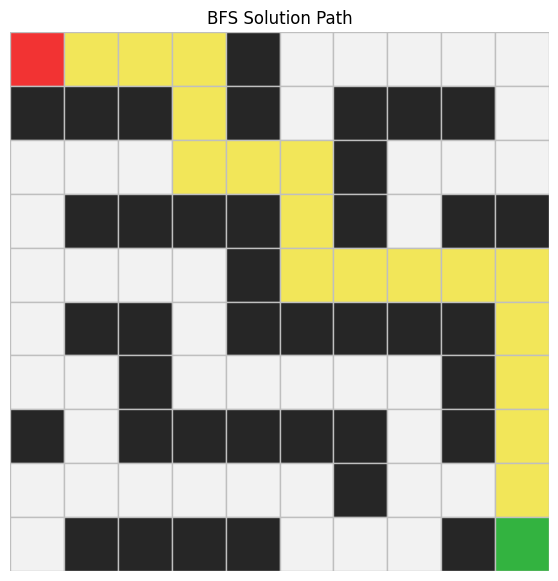

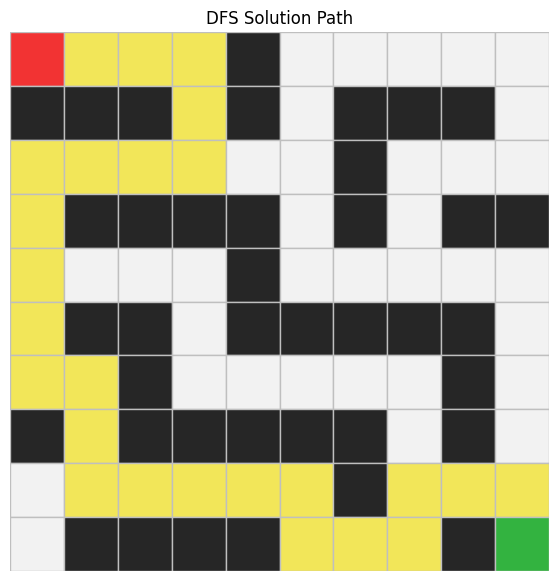

In [233]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [234]:
# 14. Create Your Own Maps

# TODO 10:
# Create your first custom map here.
custom_grid_1 = [
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0],
]
custom_start_1 = (0, 0)
custom_goal_1 = (4, 5)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)


custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),

]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,9,9,13,3,15
1,DFS,success,NaN,45,45,56,5,60
2,DLS,success,20.0,9,9,46,21,0
3,IDS,success,9.0,9,9,52,10,0


In [235]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    # Replace this with your own grid.

    [0,0,0,0],
    [0,1,0,0],
    [0,0,1,0],
    [0,0,0,1]
]

custom_start_2 = (0,0)
custom_goal_2 = (3,3)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,failure,NaN,None,None,61,5,61
1,DFS,failure,NaN,None,None,61,5,61
2,DLS,failure,20.0,None,None,66,21,0
3,IDS,failure,40.0,None,None,3564,41,0


15. Reflection Questions
Answer the questions below in markdown cells.



15.1 Problem Formulation

-A state in this lab is a position
-An action is a move from a state to another
-The result function returns the new position after an action.
it is useful to separate the problem definition from the search algorithm, because the problem determines the goal to achieve, while the search algorithm is for the goal exploration.






15.2 BFS
-BFS uses a FIFO queue: because it checks the position closest to it before the farthest position, which means it guarantees the shortest route.
-BFS find the shortest path in terms of number of steps on the unweighted grid
because it looks at all the closest positions, then the next closest after the first ones.
-The reached set plays the role in BFS of keeping track of the information of all the visited




15.3 DFS
-DFS uses a stack it wants to go as deep as possible first, before checking other paths.
-No DFS is not guaranteed to find the shortest path.
Explanation.
-DFS can use less memory than BFS, when the solution is deep and the grid has few branches.
-DFS can perform badly when the grid has many branches, and the solution is close to the start.



15.4 DLS
-When the depth limit is too small it returns cutoff instead of a solution.
-"Cutoff" means when I hit the depth limit and stopped searching, while there might be a solution deeper than the solution.
-DLS is different from ordinary DFS, because DFS goes deeper until it finds the goal, while DLS doesn't go deeper than the limit.
We use path-cycle checking in DLS to prevent infinite loops, and prevents it from getting stuck.



15.5 IDS
-IDS repeat DLS with increasing limits to find the shortest path with low memory.
-IDS can be complete even though DLS with a small limit is not because IDS keeps increasing the limit until it finds the goal.
-IDS use less memory than BFS because it uses a stack Last In First Out LIFO, not a queue.
The cost of repeatedly searching from the root: IDS expands nodes multiple times, it searches from the root over and over again.




15.6 Real-World Drone Context
-In a real drone application, obstacles wind, weather, GPS signal strength may make one route safer or more practical than another
-I would choose BFS if all moves are equally costly and I only care about the fewest number of moves, because it guarantees the shortest path because it explores level by level. [link text](https://)
Explain.
- I would choose DLS if I want to limit how deep the drone is allowed to search, because  I can set a maximum depth limit.
- This grid model limitation compared with real drone navigation: Perfect knowledge because real drones have GPS errors and uncertainty.
